# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Returns

---
## Foreword

In this notebook, my goal is to replicate the design of Barber et al. (2022) that examine the evolution of returns around herding events.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [1]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# data
base = pd.read_csv("../../../data/processed/herding_events_full.csv")

# parse dates
base["date"] = pd.to_datetime(base["date"])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_88035/1235273156.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  base = pd.read_csv("../../../data/processed/herding_events_full.csv")


## 2. Event-Time Results

In this section, the goal is to examine abnormal returns from day $t = -10$ to event day $t = 20$ around herding events, where $t = 0$ implies, for a given stock $i$, $\textit{rh\_herd}_{i, t} = 1$.

In [3]:
# assert the existence of the rh_herd column
assert "rh_herd" in base.columns, "Column 'rh_herd' not found in the dataset."

As a quick reminder, we compute the number of herding events in our dataset.

In [4]:
# number of herding events
num_events = base["rh_herd"].sum()
print(f"Number of herding events: {num_events}")

Number of herding events: 5311


### 2.1. Abnormal Returns

For computing abnormal returns we will rely on a very simplisitc approach, as Barber et al. (2022) did, and simply deduct the "market return" $R_{m, t}$ from the stock return $R_{i, t}$:

$$
AR_{i, t} = R_{i, t} - R_{m, t}
$$

Furthermore, as did Barber et al. (2022), I will also inspect the evolution of buy-and-hold abnormal returns (BHARs) separately before and after the event. For example, preevent BHARs are calculated as:

$$
BHAR_{i, t} = \prod_{t = \tau - 10}^{\tau} (1 + R_{i, t}) - \prod_{t = \tau - 10}^{\tau} (1 + R_{m, t})
$$

In [5]:
# I load the CRSP value-weighted index data
crsp_idx = pd.read_csv("../../../data/raw/crsp_index.csv")

# rename column for clarity
crsp_idx.rename(columns={"DATE": "date",
                         "vwretd": "mkt_ret"}, inplace=True)

# parse dates
crsp_idx["date"] = pd.to_datetime(crsp_idx["date"], format="%Y-%m-%d")

# head
crsp_idx.head(4)

,date,mkt_ret,vwretx,ewretd,ewretx,sprtrn,spindx,totval,totcnt,usdval,usdcnt
0,2018-05-01,0.002191,0.002140,0.001574,0.001479,0.002549,2654.80,3.548203e+10,7085,3.540363e+10,7082
1,2018-05-02,-0.005574,-0.005579,0.002890,0.002867,-0.007206,2635.67,3.528057e+10,7086,3.547716e+10,7083
2,2018-05-03,-0.002256,-0.002385,-0.003678,-0.003741,-0.002254,2629.73,3.519898e+10,7091,3.528056e+10,7085
3,2018-05-04,0.012299,0.012112,0.008924,0.008808,0.012811,2663.42,3.563530e+10,7097,3.519843e+10,7089


In [6]:
# I check if there are any missing values in the mkt_ret column
missing_values = crsp_idx["mkt_ret"].isnull().sum()
print(f"Number of missing values in 'mkt_ret': {missing_values}")

Number of missing values in 'mkt_ret': 0


Since the data was loaded properly is already clean, I merge it to my base dataset by dates.

In [7]:
# merge CRSP index data with the base dataset
base = pd.merge(base, crsp_idx[["date", "mkt_ret"]], on="date", how="left")

Once this is done, I compute $AR_{i, t}$ for the dataset

In [8]:
# compute daily abnormal returns by substracting the value-weighted return from 'ret'
base['aret'] = base['ret'] - base['mkt_ret']

### 2.2. Table VIII

I now reproduce Table VIII in Barber et al. (2022).

In [9]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df = base.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# keep only rows with required core data
df = df.dropna(subset=["date", "ticker", "aret", "rh_herd"]).copy()

# identify event rows
events = df.loc[df["rh_herd"] == 1, ["ticker", "date"]].copy()
events = events.rename(columns={"date": "event_date"})
events["event_id"] = np.arange(len(events))

print(f"Number of herding events: {len(events):,}")


# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# We want relative days from -10 to +20.
# The safest way is to map each event date to the stock's trading-day index,
# then pull observations by index offset. This avoids problems with weekends/holidays.
# ------------------------------------------------------------
window_start = -10
window_end = 20

# trading-day index within ticker
df["td_idx"] = df.groupby("ticker").cumcount()

# attach td_idx of each event day
event_base = events.merge(
    df[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# create one row per event x relative day
rel_days = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel = event_base.merge(rel_days, how="cross")
event_panel["target_td_idx"] = event_panel["td_idx"] + event_panel["rel_day"]

# merge in returns at each relative day
cols_to_pull = ["ticker", "td_idx", "date", "aret"]
if {"ret", "mkt_ret"}.issubset(df.columns):
    cols_to_pull += ["ret", "mkt_ret"]

event_panel = event_panel.merge(
    df[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel = event_panel.rename(columns={"date": "obs_date"})

# keep only observations that exist in the event window
event_panel = event_panel.dropna(subset=["aret"]).copy()


# ------------------------------------------------------------
# 3. HELPER: CLUSTERED MEAN AND SE
# ------------------------------------------------------------
def clustered_mean_se(x: pd.Series, clusters: pd.Series):
    """
    Estimate mean and cluster-robust SE by running OLS on a constant.
    """
    temp = pd.DataFrame({"y": x, "g": clusters}).dropna()
    if temp.empty:
        return np.nan, np.nan, np.nan

    model = sm.OLS(temp["y"], np.ones((len(temp), 1)))
    res = model.fit(cov_type="cluster", cov_kwds={"groups": temp["g"]})

    mean = float(res.params.iloc[0])
    se = float(res.bse.iloc[0])
    pval = float(res.pvalues.iloc[0])
    return mean, se, pval


def star_format(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""


# ------------------------------------------------------------
# 4. DAILY ABNORMAL RETURN (AR) COLUMNS
# ------------------------------------------------------------
# These replicate the AR columns directly from aret.
# Standard errors are clustered by event day, matching Barber et al.
# ------------------------------------------------------------
ar_rows = []

for k in range(window_start, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"] == k].copy()

    mean_ar, se_ar, p_ar = clustered_mean_se(tmp["aret"], tmp["event_date"])
    pos_ar = tmp["aret"].gt(0).mean()

    ar_rows.append({
        "event_day": k,
        "AR": mean_ar,
        "AR_se": se_ar,
        "AR_pval": p_ar,
        "AR_sig": star_format(p_ar),
        "AR_pos": pos_ar
    })

ar_table = pd.DataFrame(ar_rows)


# ------------------------------------------------------------
# 5. BHAR COLUMNS
# ------------------------------------------------------------
# Exact replication
# ------------------------------------------------------------
bhar_rows = []

# ----- EXACT BHAR -----
# Preevent: for tau in [-10, ..., 0], cumulate from -10 to tau
for tau in range(-10, 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(-10, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

# Postevent: for tau in [1, ..., 20], cumulate from 1 to tau
for tau in range(1, 21):
    tmp = event_panel.loc[event_panel["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

bhar_table = pd.DataFrame(bhar_rows)


# ------------------------------------------------------------
# 6. FINAL TABLE
# ------------------------------------------------------------
table_viii = ar_table.merge(bhar_table, on="event_day", how="left")

# percent format helpers
def fmt_pct(x):
    return f"{100*x:.2f}%" if pd.notna(x) else ""

def fmt_pct0(x):
    return f"{100*x:.0f}%" if pd.notna(x) else ""

# pretty display version
table_viii_display = table_viii.copy()
table_viii_display["AR_fmt"] = table_viii_display["AR"].map(fmt_pct) + table_viii_display["AR_sig"]
table_viii_display["AR_se_fmt"] = table_viii_display["AR_se"].map(fmt_pct)
table_viii_display["AR_pos_fmt"] = table_viii_display["AR_pos"].map(fmt_pct0)

table_viii_display["BHAR_fmt"] = table_viii_display["BHAR"].map(fmt_pct) + table_viii_display["BHAR_sig"]
table_viii_display["BHAR_se_fmt"] = table_viii_display["BHAR_se"].map(fmt_pct)
table_viii_display["BHAR_pos_fmt"] = table_viii_display["BHAR_pos"].map(fmt_pct0)

table_viii_display = table_viii_display[[
    "event_day",
    "AR_fmt", "AR_se_fmt", "AR_pos_fmt",
    "BHAR_fmt", "BHAR_se_fmt", "BHAR_pos_fmt"
]]

print(table_viii_display.to_string(index=False))


# ------------------------------------------------------------
# 7. OPTIONAL: SPLIT INTO PREEVENT / POSTEVENT LIKE THE PAPER
# ------------------------------------------------------------
preevent = table_viii_display.loc[table_viii_display["event_day"].between(-10, 0)].copy()
postevent = table_viii_display.loc[table_viii_display["event_day"].between(1, 20)].copy()

print("\nPREEVENT")
print(preevent.to_string(index=False))

print("\nPOSTEVENT")
print(postevent.to_string(index=False))

Number of herding events: 5,292
 event_day    AR_fmt AR_se_fmt AR_pos_fmt  BHAR_fmt BHAR_se_fmt BHAR_pos_fmt
       -10     0.04%     0.13%        48%     0.04%       0.13%          48%
        -9    -0.04%     0.15%        47%     0.08%       0.24%          47%
        -8     0.34%     0.26%        47%     0.40%       0.36%          46%
        -7    -0.14%     0.16%        46%     0.21%       0.42%          46%
        -6   -0.25%*     0.13%        46%    -0.12%       0.38%          45%
        -5     0.21%     0.18%        48%     0.33%       0.54%          46%
        -4   0.33%**     0.16%        49%     0.53%       0.50%          47%
        -3  0.63%***     0.22%        48%   1.40%**       0.60%          48%
        -2   0.61%**     0.24%        50%  1.86%***       0.58%          49%
        -1  3.82%***     0.42%        56%  5.89%***       0.75%          52%
         0 13.80%***     0.86%        64% 21.74%***       1.52%          58%
         1 -1.11%***     0.24%        43% -1

These results are perfectly consistent with the ones of Barber et al. (2022). I now produce the exact same table but for the attention sample.

### 2.3. Table VIII `attention_sample`

In [10]:
attention = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")

# parse dates
attention["date"] = pd.to_datetime(attention["date"])

# assert that rh_herd column exists
assert "rh_herd" in attention.columns, "Column 'rh_herd_attention' not found in the dataset."

# number of herding events with attention
num_attention_events = attention["rh_herd"].sum()
print(f"Number of herding events with attention: {num_attention_events}")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_88035/2290022961.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  attention = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")


Number of herding events with attention: 2005


I megre with the crsp index dataset.

In [11]:
attention = pd.merge(attention, crsp_idx[["date", "mkt_ret"]], on="date", how="left")

I finally compute $AR_{i, t}$.

In [12]:
# abnormal returns for attention dataset
attention['aret'] = attention['ret'] - attention['mkt_ret']

And the exact same procedure (yes, I inefficiently overwrite my helpers...)

In [13]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df2 = attention.copy()

df2["date"] = pd.to_datetime(df2["date"])
df2 = df2.sort_values(["ticker", "date"]).reset_index(drop=True)

# keep only rows with required core data
df2 = df2.dropna(subset=["date", "ticker", "aret", "rh_herd"]).copy()

# identify event rows
events2 = df2.loc[df2["rh_herd"] == 1, ["ticker", "date"]].copy()
events2 = events2.rename(columns={"date": "event_date"})
events2["event_id"] = np.arange(len(events2))

print(f"Number of herding events: {len(events2):,}")


# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# We want relative days from -10 to +20.
# The safest way is to map each event date to the stock's trading-day index,
# then pull observations by index offset. This avoids problems with weekends/holidays.
# ------------------------------------------------------------
window_start = -10
window_end = 20

# trading-day index within ticker
df2["td_idx"] = df2.groupby("ticker").cumcount()

# attach td_idx of each event day
event_base2 = events2.merge(
    df2[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# create one row per event x relative day
rel_days2 = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel2 = event_base2.merge(rel_days2, how="cross")
event_panel2["target_td_idx"] = event_panel2["td_idx"] + event_panel2["rel_day"]

# merge in returns at each relative day
cols_to_pull = ["ticker", "td_idx", "date", "aret"]
if {"ret", "mkt_ret"}.issubset(df2.columns):
    cols_to_pull += ["ret", "mkt_ret"]

event_panel2 = event_panel2.merge(
    df2[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel2 = event_panel2.rename(columns={"date": "obs_date"})

# keep only observations that exist in the event window
event_panel2 = event_panel2.dropna(subset=["aret"]).copy()


# ------------------------------------------------------------
# 3. HELPER: CLUSTERED MEAN AND SE
# ------------------------------------------------------------
def clustered_mean_se(x: pd.Series, clusters: pd.Series):
    """
    Estimate mean and cluster-robust SE by running OLS on a constant.
    """
    temp = pd.DataFrame({"y": x, "g": clusters}).dropna()
    if temp.empty:
        return np.nan, np.nan, np.nan

    model = sm.OLS(temp["y"], np.ones((len(temp), 1)))
    res = model.fit(cov_type="cluster", cov_kwds={"groups": temp["g"]})

    mean = float(res.params.iloc[0])
    se = float(res.bse.iloc[0])
    pval = float(res.pvalues.iloc[0])
    return mean, se, pval


def star_format(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""


# ------------------------------------------------------------
# 4. DAILY ABNORMAL RETURN (AR) COLUMNS
# ------------------------------------------------------------
# These replicate the AR columns directly from aret.
# Standard errors are clustered by event day, matching Barber et al.
# ------------------------------------------------------------
ar_rows2 = []

for k in range(window_start, window_end + 1):
    tmp = event_panel2.loc[event_panel2["rel_day"] == k].copy()

    mean_ar, se_ar, p_ar = clustered_mean_se(tmp["aret"], tmp["event_date"])
    pos_ar = tmp["aret"].gt(0).mean()

    ar_rows2.append({
        "event_day": k,
        "AR": mean_ar,
        "AR_se": se_ar,
        "AR_pval": p_ar,
        "AR_sig": star_format(p_ar),
        "AR_pos": pos_ar
    })

ar_table2 = pd.DataFrame(ar_rows2)


# ------------------------------------------------------------
# 5. BHAR COLUMNS
# ------------------------------------------------------------
# Exact replication
# ------------------------------------------------------------
bhar_rows2 = []

# ----- EXACT BHAR -----
# Preevent: for tau in [-10, ..., 0], cumulate from -10 to tau
for tau in range(-10, 1):
    tmp = event_panel2.loc[event_panel2["rel_day"].between(-10, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows2.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

# Postevent: for tau in [1, ..., 20], cumulate from 1 to tau
for tau in range(1, 21):
    tmp = event_panel2.loc[event_panel2["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows2.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

bhar_table2 = pd.DataFrame(bhar_rows2)


# ------------------------------------------------------------
# 6. FINAL TABLE
# ------------------------------------------------------------
table_viii_2 = ar_table2.merge(bhar_table2, on="event_day", how="left")

# percent format helpers
def fmt_pct(x):
    return f"{100*x:.2f}%" if pd.notna(x) else ""

def fmt_pct0(x):
    return f"{100*x:.0f}%" if pd.notna(x) else ""

# pretty display version
table_viii_display_2 = table_viii_2.copy()
table_viii_display_2["AR_fmt"] = table_viii_display_2["AR"].map(fmt_pct) + table_viii_display_2["AR_sig"]
table_viii_display_2["AR_se_fmt"] = table_viii_display_2["AR_se"].map(fmt_pct)
table_viii_display_2["AR_pos_fmt"] = table_viii_display_2["AR_pos"].map(fmt_pct0)

table_viii_display_2["BHAR_fmt"] = table_viii_display_2["BHAR"].map(fmt_pct) + table_viii_display_2["BHAR_sig"]
table_viii_display_2["BHAR_se_fmt"] = table_viii_display_2["BHAR_se"].map(fmt_pct)
table_viii_display_2["BHAR_pos_fmt"] = table_viii_display_2["BHAR_pos"].map(fmt_pct0)

table_viii_display_2 = table_viii_display_2[[
    "event_day",
    "AR_fmt", "AR_se_fmt", "AR_pos_fmt",
    "BHAR_fmt", "BHAR_se_fmt", "BHAR_pos_fmt"
]]

print(table_viii_display_2.to_string(index=False))


# ------------------------------------------------------------
# 7. OPTIONAL: SPLIT INTO PREEVENT / POSTEVENT LIKE THE PAPER
# ------------------------------------------------------------
preevent2 = table_viii_display_2.loc[table_viii_display_2["event_day"].between(-10, 0)].copy()
postevent2 = table_viii_display_2.loc[table_viii_display_2["event_day"].between(1, 20)].copy()

print("\nPREEVENT")
print(preevent2.to_string(index=False))

print("\nPOSTEVENT")
print(postevent2.to_string(index=False))

Number of herding events: 2,005
 event_day    AR_fmt AR_se_fmt AR_pos_fmt  BHAR_fmt BHAR_se_fmt BHAR_pos_fmt
       -10    -0.09%     0.13%        49%    -0.09%       0.13%          49%
        -9    -0.17%     0.14%        48%    -0.24%       0.19%          48%
        -8    -0.01%     0.16%        48%    -0.32%       0.22%          47%
        -7    -0.02%     0.16%        48%    -0.38%       0.27%          48%
        -6    -0.23%     0.14%        47%   -0.59%*       0.31%          46%
        -5    -0.02%     0.15%        49%    -0.52%       0.36%          47%
        -4    -0.16%     0.16%        49%    -0.53%       0.47%          47%
        -3    -0.19%     0.17%        49%    -0.65%       0.47%          48%
        -2  -0.46%**     0.22%        49%   -0.97%*       0.51%          48%
        -1     0.75%     0.58%        52%    -0.10%       0.74%          48%
         0  2.51%***     0.66%        55%  2.82%***       1.08%          47%
         1     0.04%     0.29%        48%   

We see that with the attention sample we fail to reproduce cleanly Barber et al. (2022) results.

### 2.4. Reproducing Figure 6

In [14]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df = base.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

req = ["date", "ticker", "rh_herd", "userchg", "ret", "mkt_ret"]
df = df.dropna(subset=req).copy()

# trading-day index within ticker
df["td_idx"] = df.groupby("ticker").cumcount()

# event list
events = df.loc[df["rh_herd"] == 1, ["ticker", "date"]].copy()
events = events.rename(columns={"date": "event_date"})
events["event_id"] = np.arange(len(events))

print(f"Number of herding events: {len(events):,}")

# attach td_idx of each event day
event_base = events.merge(
    df[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# Figure caption says 10 days before to 21 days after.
# The paper plot appears to show points up to 20.
# To match the visible figure, use -10 to +20.
# If you want the literal caption, set window_end = 21.
# ------------------------------------------------------------
window_start = -10
window_end = 20

rel_days = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel = event_base.merge(rel_days, how="cross")
event_panel["target_td_idx"] = event_panel["td_idx"] + event_panel["rel_day"]

# pull event-time observations
cols_to_pull = ["ticker", "td_idx", "date", "userchg", "ret", "mkt_ret"]
event_panel = event_panel.merge(
    df[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel = event_panel.rename(columns={"date": "obs_date"})
event_panel = event_panel.dropna(subset=["userchg", "ret", "mkt_ret"]).copy()
event_panel = event_panel.sort_values(["event_id", "rel_day"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. MEAN USER CHANGE BY EVENT TIME
# ------------------------------------------------------------
# Gray bars in the left panel
# ------------------------------------------------------------
mean_userchg = (
    event_panel.groupby("rel_day", as_index=False)["userchg"]
    .mean()
    .rename(columns={"userchg": "mean_userchg"})
)

# ------------------------------------------------------------
# 4. MEAN BHAR BY EVENT TIME
# ------------------------------------------------------------
# LEFT PANEL:
# For each event day tau in [-10, ..., 20], compute BHAR from -10 to tau
#
# RIGHT PANEL:
# For each event day tau in [0, ..., 20], compute postevent BHAR starting at day 0
#
# This matches the figure caption language.
# If you wanted to mimic Table VIII exactly, postevent BHAR would start at day 1.
# But Figure 6 explicitly says "starting from day 0."
# ------------------------------------------------------------

# ---- Left-panel BHAR: cumulate from -10 to tau
left_bhar_rows = []

for tau in range(window_start, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(window_start, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    left_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

left_bhar = pd.DataFrame(left_bhar_rows)

# ---- Right-panel BHAR: postevent path starting at day 0 = 0
# day 0 is normalized to 0
right_bhar_rows = [{"rel_day": 0, "mean_bhar": 0.0}]

for tau in range(1, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    right_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

right_bhar = pd.DataFrame(right_bhar_rows)

Number of herding events: 5,282


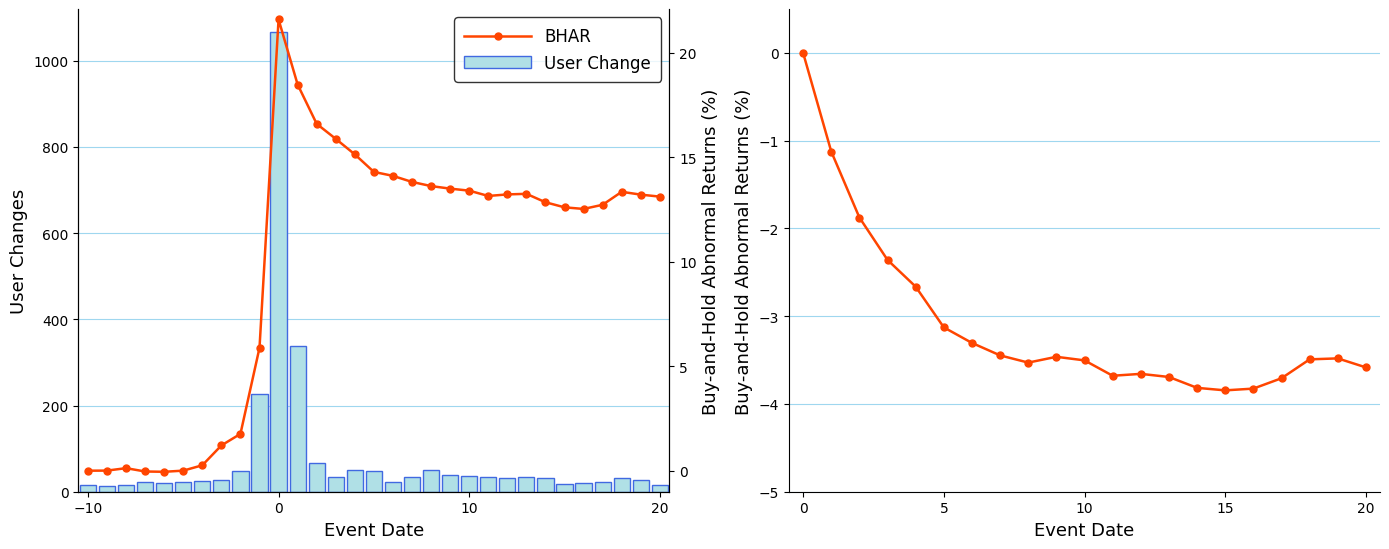

In [15]:
# ------------------------------------------------------------
# 6. PLOT FIGURE 6
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax1 = axes[0]
ax2 = axes[1]

# ----- Left panel: bars + BHAR line on twin axis
bars = ax1.bar(
    mean_userchg["rel_day"],
    mean_userchg["mean_userchg"],
    width=0.85,
    color="powderblue",
    edgecolor="royalblue",
    linewidth=1.0,
    label="User Change",
    zorder=1
)

ax1.set_xlabel("Event Date", fontsize=13)
ax1.set_ylabel("User Changes", fontsize=13)
ax1.set_xlim(window_start - 0.5, window_end + 0.5)
ax1.set_xticks([-10, 0, 10, 20])
ax1.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax1.set_axisbelow(True)

ax1b = ax1.twinx()
line1, = ax1b.plot(
    left_bhar["rel_day"],
    100 * left_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    label="BHAR",
    zorder=3
)

ax1b.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax1b.set_ylim(min(-1, 100 * left_bhar["mean_bhar"].min() - 0.5),
              max(22, 100 * left_bhar["mean_bhar"].max() + 0.5))

# legend matching order in paper
handles = [line1, bars]
labels = ["BHAR", "User Change"]
ax1.legend(
    handles, labels,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=12,
    handlelength=4,
    borderpad=0.6
)

# ----- Right panel: postevent BHAR only
ax2.plot(
    right_bhar["rel_day"],
    100 * right_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    zorder=3
)

ax2.set_xlabel("Event Date", fontsize=13)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax2.set_xlim(-0.5, window_end + 0.5)
ax2.set_xticks([0, 5, 10, 15, 20])
ax2.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax2.set_axisbelow(True)

# set right-panel y-range close to published figure
ax2.set_ylim(-5, 0.5)

# cosmetic cleanup
for ax in [ax1, ax2, ax1b]:
    ax.spines["top"].set_visible(False)

ax2.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("../../../figures/figure_6_replication.pdf", bbox_inches="tight")
plt.show()

And for the attention sample, even if I excpect the figure to not as neat as the one above; which replicates very well Barber et al. (2022).

In [16]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df = attention.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

req = ["date", "ticker", "rh_herd", "userchg", "ret", "mkt_ret"]
df = df.dropna(subset=req).copy()

# trading-day index within ticker
df["td_idx"] = df.groupby("ticker").cumcount()

# event list
events = df.loc[df["rh_herd"] == 1, ["ticker", "date"]].copy()
events = events.rename(columns={"date": "event_date"})
events["event_id"] = np.arange(len(events))

print(f"Number of herding events: {len(events):,}")

# attach td_idx of each event day
event_base = events.merge(
    df[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# Figure caption says 10 days before to 21 days after.
# The paper plot appears to show points up to 20.
# To match the visible figure, use -10 to +20.
# If you want the literal caption, set window_end = 21.
# ------------------------------------------------------------
window_start = -10
window_end = 20

rel_days = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel = event_base.merge(rel_days, how="cross")
event_panel["target_td_idx"] = event_panel["td_idx"] + event_panel["rel_day"]

# pull event-time observations
cols_to_pull = ["ticker", "td_idx", "date", "userchg", "ret", "mkt_ret"]
event_panel = event_panel.merge(
    df[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel = event_panel.rename(columns={"date": "obs_date"})
event_panel = event_panel.dropna(subset=["userchg", "ret", "mkt_ret"]).copy()
event_panel = event_panel.sort_values(["event_id", "rel_day"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. MEAN USER CHANGE BY EVENT TIME
# ------------------------------------------------------------
# Gray bars in the left panel
# ------------------------------------------------------------
mean_userchg = (
    event_panel.groupby("rel_day", as_index=False)["userchg"]
    .mean()
    .rename(columns={"userchg": "mean_userchg"})
)

# ------------------------------------------------------------
# 4. MEAN BHAR BY EVENT TIME
# ------------------------------------------------------------
# LEFT PANEL:
# For each event day tau in [-10, ..., 20], compute BHAR from -10 to tau
#
# RIGHT PANEL:
# For each event day tau in [0, ..., 20], compute postevent BHAR starting at day 0
#
# This matches the figure caption language.
# If you wanted to mimic Table VIII exactly, postevent BHAR would start at day 1.
# But Figure 6 explicitly says "starting from day 0."
# ------------------------------------------------------------

# ---- Left-panel BHAR: cumulate from -10 to tau
left_bhar_rows = []

for tau in range(window_start, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(window_start, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    left_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

left_bhar = pd.DataFrame(left_bhar_rows)

# ---- Right-panel BHAR: postevent path starting at day 0 = 0
# day 0 is normalized to 0
right_bhar_rows = [{"rel_day": 0, "mean_bhar": 0.0}]

for tau in range(1, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    right_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

right_bhar = pd.DataFrame(right_bhar_rows)

Number of herding events: 2,001


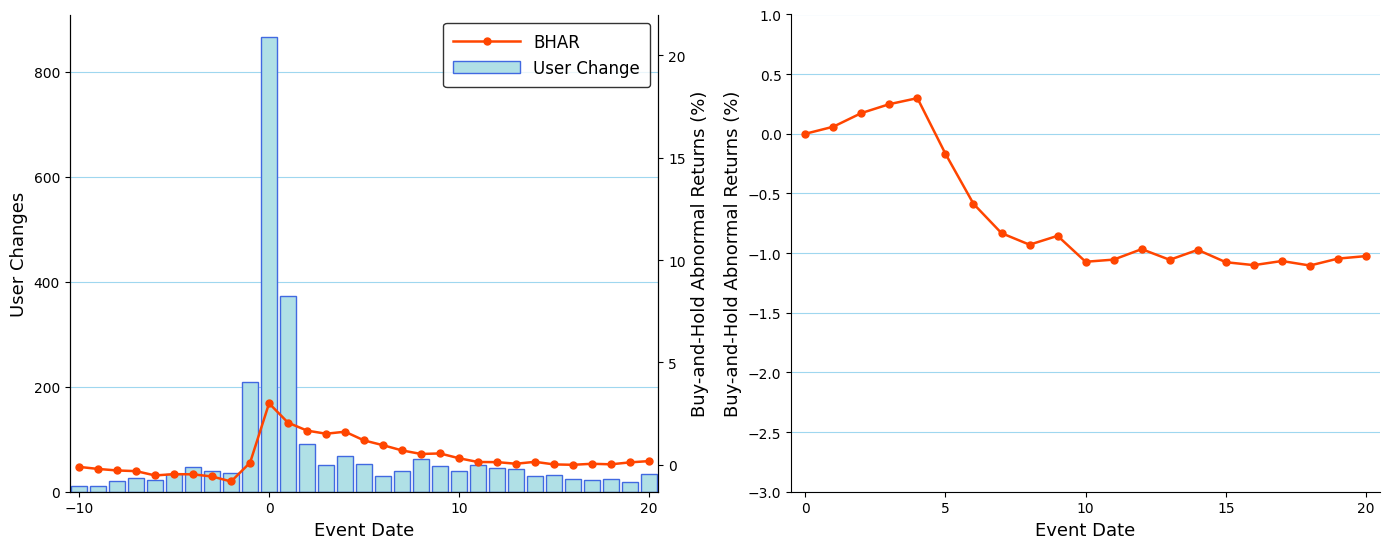

In [17]:
# ------------------------------------------------------------
# 6. PLOT FIGURE 6
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax1 = axes[0]
ax2 = axes[1]

# ----- Left panel: bars + BHAR line on twin axis
bars = ax1.bar(
    mean_userchg["rel_day"],
    mean_userchg["mean_userchg"],
    width=0.85,
    color="powderblue",
    edgecolor="royalblue",
    linewidth=1.0,
    label="User Change",
    zorder=1
)

ax1.set_xlabel("Event Date", fontsize=13)
ax1.set_ylabel("User Changes", fontsize=13)
ax1.set_xlim(window_start - 0.5, window_end + 0.5)
ax1.set_xticks([-10, 0, 10, 20])
ax1.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax1.set_axisbelow(True)

ax1b = ax1.twinx()
line1, = ax1b.plot(
    left_bhar["rel_day"],
    100 * left_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    label="BHAR",
    zorder=3
)

ax1b.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax1b.set_ylim(min(-1, 100 * left_bhar["mean_bhar"].min() - 0.5),
              max(22, 100 * left_bhar["mean_bhar"].max() + 0.5))

# legend matching order in paper
handles = [line1, bars]
labels = ["BHAR", "User Change"]
ax1.legend(
    handles, labels,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=12,
    handlelength=4,
    borderpad=0.6
)

# ----- Right panel: postevent BHAR only
ax2.plot(
    right_bhar["rel_day"],
    100 * right_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    zorder=3
)

ax2.set_xlabel("Event Date", fontsize=13)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax2.set_xlim(-0.5, window_end + 0.5)
ax2.set_xticks([0, 5, 10, 15, 20])
ax2.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax2.set_axisbelow(True)

# set right-panel y-range close to published figure
ax2.set_ylim(-3, 1)

# cosmetic cleanup
for ax in [ax1, ax2, ax1b]:
    ax.spines["top"].set_visible(False)

ax2.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("../../../figures/figure_6_attention_replication.pdf", bbox_inches="tight")
plt.show()

### 2.5 Reproduction of Figure 7

Reproducing figure 7 requires a little more work because we have to define herding events for a range of different $\textit{userratio}_{i, t}$.

In [18]:
# ============================================================
# LOAD DATA
# ============================================================
base2 = pd.read_csv("../../../data/processed/baseline_trading_sample.csv")

base2["date"] = pd.to_datetime(base2["date"])
crsp_idx["date"] = pd.to_datetime(crsp_idx["date"])

base2 = pd.merge(base2, crsp_idx[["date", "mkt_ret"]], on="date", how="left")
base2["aret"] = base2["ret"] - base2["mkt_ret"]

base2 = base2.sort_values(["ticker", "date"]).reset_index(drop=True)
base2["users_close_lag1"] = base2.groupby("ticker")["users_close"].shift(1)
base2["userratio"] = base2["users_close"] / base2["users_close_lag1"]
base2["userratio"] = base2["userratio"].replace([np.inf, -np.inf], np.nan)
base2["td_idx"] = base2.groupby("ticker").cumcount()

base2 = base2.dropna(
    subset=["ticker", "date", "ret", "mkt_ret", "userratio", "users_close_lag1", "td_idx"]
).copy()


# ============================================================
# FUNCTION: EVENT COUNT + 20-DAY POSTEVENT BHAR + 90% CI
# ============================================================
def compute_fig7_stats_for_cutoff(df, cutoff, z=1.645):
    events = df.loc[
        (df["userratio"] >= cutoff) &
        (df["users_close_lag1"] >= 100),
        ["ticker", "date", "td_idx"]
    ].copy()

    n_events = len(events)
    if n_events == 0:
        return {
            "n_events": 0,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    events = events.rename(columns={"date": "event_date", "td_idx": "event_td_idx"})
    events["event_id"] = np.arange(n_events)

    # days +1 to +20
    rel_days = pd.DataFrame({"rel_day": np.arange(1, 21)})
    panel = events.merge(rel_days, how="cross")
    panel["target_td_idx"] = panel["event_td_idx"] + panel["rel_day"]

    panel = panel.merge(
        df[["ticker", "td_idx", "ret", "mkt_ret"]],
        left_on=["ticker", "target_td_idx"],
        right_on=["ticker", "td_idx"],
        how="left"
    )

    panel = panel.dropna(subset=["ret", "mkt_ret"]).copy()

    counts = panel.groupby("event_id")["rel_day"].nunique()
    valid_ids = counts[counts == 20].index

    if len(valid_ids) == 0:
        return {
            "n_events": n_events,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    panel = panel[panel["event_id"].isin(valid_ids)].copy()

    event_bhar = (
        panel.sort_values(["event_id", "rel_day"])
             .groupby("event_id", as_index=False)
             .agg(
                 stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
                 mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
             )
    )
    event_bhar["bhar_20d"] = event_bhar["stock_leg"] - event_bhar["mkt_leg"]

    x = event_bhar["bhar_20d"]
    n_complete = len(x)
    mean_bhar = x.mean()

    # standard error of the mean
    se_bhar = x.std(ddof=1) / np.sqrt(n_complete) if n_complete > 1 else np.nan

    ci_low = mean_bhar - z * se_bhar if pd.notna(se_bhar) else np.nan
    ci_high = mean_bhar + z * se_bhar if pd.notna(se_bhar) else np.nan

    return {
        "n_events": n_events,
        "bhar_20d": mean_bhar,
        "se_bhar_20d": se_bhar,
        "ci90_low": ci_low,
        "ci90_high": ci_high,
        "n_complete": n_complete
    }


# ============================================================
# SWEEP OVER CUTOFFS
# ============================================================
cutoffs = np.round(np.arange(1.1, 8.5 + 0.001, 0.1), 1)

results = []
for c in cutoffs:
    out = compute_fig7_stats_for_cutoff(base2, c)
    results.append({
        "cutoff": c,
        **out
    })

fig7_df = pd.DataFrame(results)

fig7_df.head()

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_88035/3266820942.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  base2 = pd.read_csv("../../../data/processed/baseline_trading_sample.csv")


,cutoff,n_events,bhar_20d,se_bhar_20d,ci90_low,ci90_high,n_complete
0,1.1,20852,-0.003468,0.003011,-0.008420,0.001485,15342
1,1.2,9070,-0.019912,0.004765,-0.027749,-0.012074,6708
2,1.3,5574,-0.030048,0.006239,-0.040311,-0.019785,4122
3,1.4,3978,-0.036131,0.006576,-0.046948,-0.025314,2932
4,1.5,3018,-0.037821,0.007647,-0.050401,-0.025241,2238


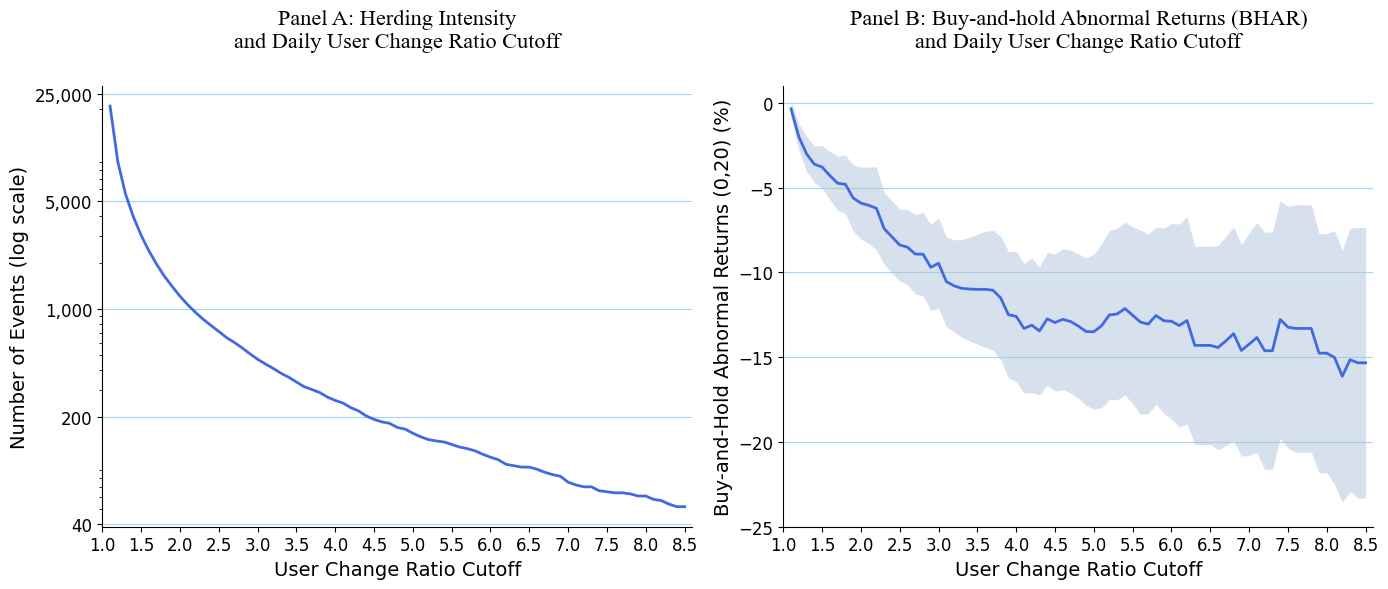

In [95]:
plot_b = fig7_df.dropna(subset=["bhar_20d"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------- Panel A ----------------
ax1 = axes[0]
ax1.plot(
    fig7_df["cutoff"],
    fig7_df["n_events"],
    color="royalblue",
    linewidth=2
)
ax1.set_title(
    "Panel A: Herding Intensity\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax1.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax1.set_ylabel("Number of Events (log scale)", fontsize=14)
ax1.set_yscale("log")
ax1.set_xlim(1.0, 8.6)
ax1.set_xticks(np.arange(1.0, 8.6, 0.5))
ax1.set_yticks([40, 200, 1000, 5000, 25000])
ax1.set_yticklabels(["40", "200", "1,000", "5,000", "25,000"])
ax1.grid(axis="y", alpha=0.8, color="skyblue")
ax1.set_axisbelow(True)

# ---------------- Panel B ----------------
ax2 = axes[1]
ax2.plot(
    plot_b["cutoff"],
    100 * plot_b["bhar_20d"],
    color="royalblue",
    linewidth=2
)
# 90% confidence band
ax2.fill_between(
    plot_b["cutoff"],
    100 * plot_b["ci90_low"],
    100 * plot_b["ci90_high"],
    color="lightsteelblue",
    alpha=0.5,
    linewidth=0
)
ax2.set_title(
    "Panel B: Buy-and-hold Abnormal Returns (BHAR)\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax2.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (0,20) (%)", fontsize=14)
ax2.set_xlim(1.0, 8.6)
ax2.set_xticks(np.arange(1.0, 8.6, 0.5))
ax2.set_ylim(-25, 1)
ax2.set_yticks([0, -5, -10, -15, -20, -25])
ax2.grid(axis="y", alpha=0.8, color="skyblue")
ax2.set_axisbelow(True)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig("../../../figures/figure_7_replication_baseline.pdf", bbox_inches="tight")
plt.show()

I again reproduce the same thing but for the attention sample.

In [96]:
# ============================================================
# LOAD DATA
# ============================================================
base2 = pd.read_csv("../../../data/processed/attention_sample.csv")

base2["date"] = pd.to_datetime(base2["date"])
crsp_idx["date"] = pd.to_datetime(crsp_idx["date"])

base2 = pd.merge(base2, crsp_idx[["date", "mkt_ret"]], on="date", how="left")
base2["aret"] = base2["ret"] - base2["mkt_ret"]

base2 = base2.sort_values(["ticker", "date"]).reset_index(drop=True)
base2["users_close_lag1"] = base2.groupby("ticker")["users_close"].shift(1)
base2["userratio"] = base2["users_close"] / base2["users_close_lag1"]
base2["userratio"] = base2["userratio"].replace([np.inf, -np.inf], np.nan)
base2["td_idx"] = base2.groupby("ticker").cumcount()

base2 = base2.dropna(
    subset=["ticker", "date", "ret", "mkt_ret", "userratio", "users_close_lag1", "td_idx"]
).copy()


# ============================================================
# FUNCTION: EVENT COUNT + 20-DAY POSTEVENT BHAR + 90% CI
# ============================================================
def compute_fig7_stats_for_cutoff(df, cutoff, z=1.645):
    events = df.loc[
        (df["userratio"] >= cutoff) &
        (df["users_close_lag1"] >= 100),
        ["ticker", "date", "td_idx"]
    ].copy()

    n_events = len(events)
    if n_events == 0:
        return {
            "n_events": 0,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    events = events.rename(columns={"date": "event_date", "td_idx": "event_td_idx"})
    events["event_id"] = np.arange(n_events)

    # days +1 to +20
    rel_days = pd.DataFrame({"rel_day": np.arange(1, 21)})
    panel = events.merge(rel_days, how="cross")
    panel["target_td_idx"] = panel["event_td_idx"] + panel["rel_day"]

    panel = panel.merge(
        df[["ticker", "td_idx", "ret", "mkt_ret"]],
        left_on=["ticker", "target_td_idx"],
        right_on=["ticker", "td_idx"],
        how="left"
    )

    panel = panel.dropna(subset=["ret", "mkt_ret"]).copy()

    counts = panel.groupby("event_id")["rel_day"].nunique()
    valid_ids = counts[counts == 20].index

    if len(valid_ids) == 0:
        return {
            "n_events": n_events,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    panel = panel[panel["event_id"].isin(valid_ids)].copy()

    event_bhar = (
        panel.sort_values(["event_id", "rel_day"])
             .groupby("event_id", as_index=False)
             .agg(
                 stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
                 mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
             )
    )
    event_bhar["bhar_20d"] = event_bhar["stock_leg"] - event_bhar["mkt_leg"]

    x = event_bhar["bhar_20d"]
    n_complete = len(x)
    mean_bhar = x.mean()

    # standard error of the mean
    se_bhar = x.std(ddof=1) / np.sqrt(n_complete) if n_complete > 1 else np.nan

    ci_low = mean_bhar - z * se_bhar if pd.notna(se_bhar) else np.nan
    ci_high = mean_bhar + z * se_bhar if pd.notna(se_bhar) else np.nan

    return {
        "n_events": n_events,
        "bhar_20d": mean_bhar,
        "se_bhar_20d": se_bhar,
        "ci90_low": ci_low,
        "ci90_high": ci_high,
        "n_complete": n_complete
    }


# ============================================================
# SWEEP OVER CUTOFFS
# ============================================================
cutoffs = np.round(np.arange(1.1, 4.0 + 0.001, 0.1), 1)

results = []
for c in cutoffs:
    out = compute_fig7_stats_for_cutoff(base2, c)
    results.append({
        "cutoff": c,
        **out
    })

fig7_df = pd.DataFrame(results)

fig7_df.head()

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_54930/3791843490.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  base2 = pd.read_csv("../../../data/processed/attention_sample.csv")


,cutoff,n_events,bhar_20d,se_bhar_20d,ci90_low,ci90_high,n_complete
0,1.1,5537,0.007385,0.004025,0.000765,0.014006,4150
1,1.2,2260,0.001630,0.006939,-0.009785,0.013045,1675
2,1.3,1360,-0.004759,0.007715,-0.017451,0.007932,1007
3,1.4,951,-0.008743,0.009408,-0.024219,0.006734,706
4,1.5,679,-0.003981,0.010421,-0.021125,0.013162,513


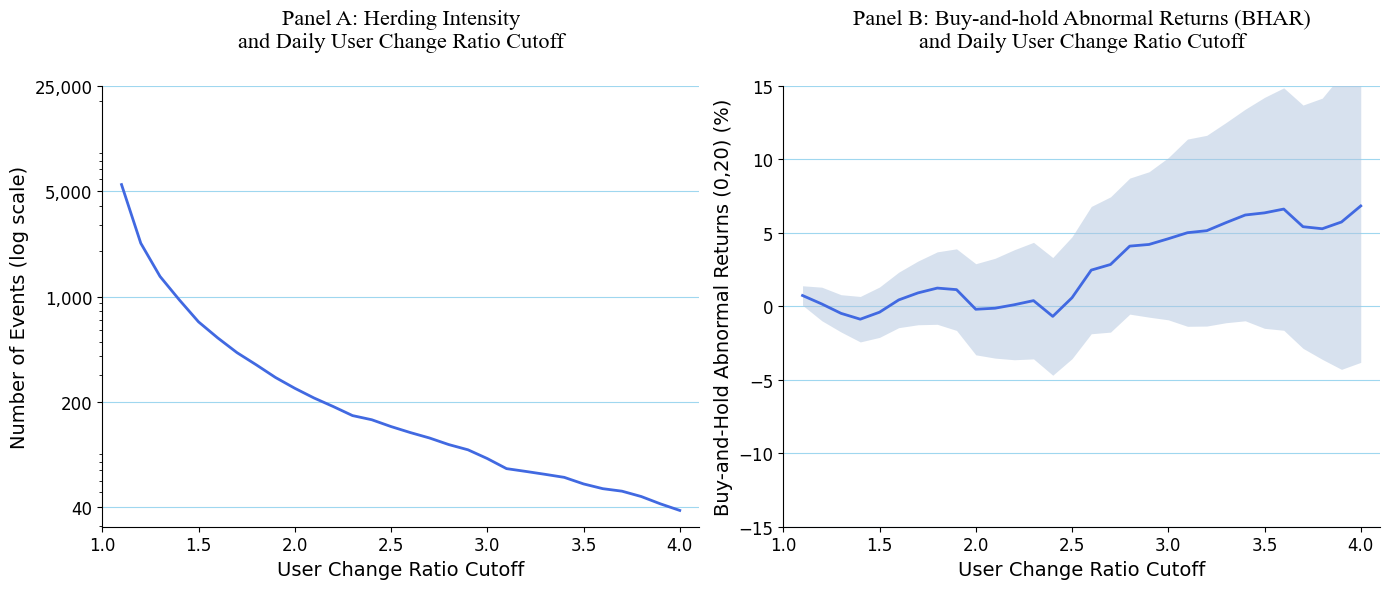

In [97]:
plot_b = fig7_df.dropna(subset=["bhar_20d"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------- Panel A ----------------
ax1 = axes[0]
ax1.plot(
    fig7_df["cutoff"],
    fig7_df["n_events"],
    color="royalblue",
    linewidth=2
)
ax1.set_title(
    "Panel A: Herding Intensity\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax1.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax1.set_ylabel("Number of Events (log scale)", fontsize=14)
ax1.set_yscale("log")
ax1.set_xlim(1.0, 4.1)
ax1.set_xticks(np.arange(1.0, 4.3, 0.5))
ax1.set_yticks([40, 200, 1000, 5000, 25000])
ax1.set_yticklabels(["40", "200", "1,000", "5,000", "25,000"])
ax1.grid(axis="y", alpha=0.8, color="skyblue")
ax1.set_axisbelow(True)

# ---------------- Panel B ----------------
ax2 = axes[1]
ax2.plot(
    plot_b["cutoff"],
    100 * plot_b["bhar_20d"],
    color="royalblue",
    linewidth=2
)
# 90% confidence band
ax2.fill_between(
    plot_b["cutoff"],
    100 * plot_b["ci90_low"],
    100 * plot_b["ci90_high"],
    color="lightsteelblue",
    alpha=0.5,
    linewidth=0
)
ax2.set_title(
    "Panel B: Buy-and-hold Abnormal Returns (BHAR)\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax2.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (0,20) (%)", fontsize=14)
ax2.set_xlim(1.0, 4.1)
ax2.set_xticks(np.arange(1.0, 4.3, 0.5))
ax2.set_ylim(-15, 15)
ax2.set_yticks([-15, -10, -5, 0, 5, 10, 15])
ax2.grid(axis="y", alpha=0.8, color="skyblue")
ax2.set_axisbelow(True)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig("../../../figures/figure_7_replication_attention.pdf", bbox_inches="tight")
plt.show()

Considering earlier results, it is not surprising that the attention sample does not reproduce the findings of Barber et al. (2022).

## 3. Calendar Time Strategy

In [130]:
# data baseline trading sample
df3 = base.copy()

# data attention sample
# df3 = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")
# df3["date"] = pd.to_datetime(df3["date"])
# df3 = df3.sort_values(["ticker", "date"]).reset_index(drop=True)

To address the cross-sectional dependence issue underlying event-time analyses and to investigate the returns earned on a trading strategy that follows the herding episodes, I follow Barber et al. (2022) and construct a calendar-time portfolio that invests $\$1$ in each herding episode stock at the close of the event day and holds the stock for five days (without rebalancing). I estimate the $\alpha$ of the portfolio by regressing the portfolio excess returns on Fama French five factors:

$$
R_{pt} - R_{ft} = \alpha + \beta (R_{mt} - R_{ft}) + \sum_{k = 1}^{K} c_k F_t^{k} + u_{pt}
$$

### 3.1. Building the Portfolio Returns $\{R_{pt}\}$

First I should build the portfolio returns series for each day $t$.

In [19]:
def build_herding_calendar_time_portfolio(
    df: pd.DataFrame,
    date_col: str = "date",
    ticker_col: str = "ticker",
    event_col: str = "rh_herd",
    ret_col: str = "ret",
    holding_days: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build a calendar-time portfolio return series following Robinhood herding episodes.

    Design:
    - A herding event occurs when rh_herd == 1 for stock i on day t.
    - The strategy invests $1 at the close of event day t.
    - It earns stock returns from t+1 through t+5, using trading days.
    - Overlapping events in the same stock are treated as distinct positions.
    - On each calendar day, the portfolio return is the equal-weighted average
      return across all active event-positions.
    - Missing stock returns are dropped only for that stock-day position.

    Returns
    -------
    portfolio_returns : pd.DataFrame
        Daily calendar-time portfolio returns with columns:
        date, rp, n_active_positions, n_unique_tickers.

    active_positions : pd.DataFrame
        Event-position level dataset used to construct the portfolio.
    """

    # ------------------------------------------------------------
    # 1. Basic cleaning and validation
    # ------------------------------------------------------------

    required_cols = {date_col, ticker_col, event_col, ret_col}
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    data = df[[date_col, ticker_col, event_col, ret_col]].copy()

    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values([ticker_col, date_col])

    # Enforce numeric returns
    data[ret_col] = pd.to_numeric(data[ret_col], errors="coerce")

    # Optional but useful: check whether ticker-date observations are unique
    duplicate_mask = data.duplicated(subset=[ticker_col, date_col], keep=False)
    if duplicate_mask.any():
        n_duplicates = duplicate_mask.sum()
        raise ValueError(
            f"There are {n_duplicates} duplicated ticker-date rows. "
            "You should resolve duplicates before constructing the portfolio."
        )

    # ------------------------------------------------------------
    # 2. Build the trading-day calendar
    # ------------------------------------------------------------

    trading_calendar = (
        pd.DataFrame({date_col: sorted(data[date_col].dropna().unique())})
        .reset_index()
        .rename(columns={"index": "trading_day_index"})
    )

    data = data.merge(trading_calendar, on=date_col, how="left")

    max_trading_day_index = trading_calendar["trading_day_index"].max()

    # ------------------------------------------------------------
    # 3. Identify herding events
    # ------------------------------------------------------------

    events = data.loc[data[event_col] == 1, [date_col, ticker_col, "trading_day_index"]].copy()

    events = events.rename(
        columns={
            date_col: "event_date",
            "trading_day_index": "event_trading_day_index",
        }
    )

    events = events.reset_index(drop=True)
    events["event_id"] = np.arange(len(events))

    if events.empty:
        portfolio_returns = pd.DataFrame(
            columns=[date_col, "rp", "n_active_positions", "n_unique_tickers"]
        )
        active_positions = pd.DataFrame()
        return portfolio_returns, active_positions

    # ------------------------------------------------------------
    # 4. Expand each event into five future trading-day positions
    # ------------------------------------------------------------

    horizons = pd.DataFrame({"holding_day": np.arange(1, holding_days + 1)})

    active_positions = events.merge(horizons, how="cross")

    active_positions["target_trading_day_index"] = (
        active_positions["event_trading_day_index"] + active_positions["holding_day"]
    )

    # Drop positions whose holding window goes beyond the available sample
    active_positions = active_positions.loc[
        active_positions["target_trading_day_index"] <= max_trading_day_index
    ].copy()

    # Attach the actual target date
    active_positions = active_positions.merge(
        trading_calendar.rename(
            columns={
                date_col: "date",
                "trading_day_index": "target_trading_day_index",
            }
        ),
        on="target_trading_day_index",
        how="left",
    )

    # ------------------------------------------------------------
    # 5. Merge realized stock returns for each active position
    # ------------------------------------------------------------

    returns = data[[date_col, ticker_col, ret_col]].rename(
        columns={
            date_col: "date",
            ret_col: "position_ret",
        }
    )

    active_positions = active_positions.merge(
        returns,
        on=["date", ticker_col],
        how="left",
    )

    # Drop only missing stock-day returns, not the full event
    active_positions = active_positions.dropna(subset=["position_ret"]).copy()

    # ------------------------------------------------------------
    # 6. Compute daily equal-weighted portfolio return
    # ------------------------------------------------------------

    portfolio_returns = (
        active_positions
        .groupby("date", as_index=False)
        .agg(
            rp=("position_ret", "mean"),
            n_active_positions=("position_ret", "size"),
            n_unique_tickers=(ticker_col, "nunique"),
        )
        .sort_values("date")
        .reset_index(drop=True)
    )

    return portfolio_returns, active_positions

In [132]:
portfolio_returns, active_positions = build_herding_calendar_time_portfolio(df3)

portfolio_returns.head()

,date,rp,n_active_positions,n_unique_tickers
0,2018-05-07,-0.056704,1,1
1,2018-05-08,-0.032022,1,1
2,2018-05-09,0.167731,1,1
3,2018-05-10,0.006353,8,8
4,2018-05-11,-0.008456,15,15


As a first inspection I plot the number of active positions over time in the portfolio.

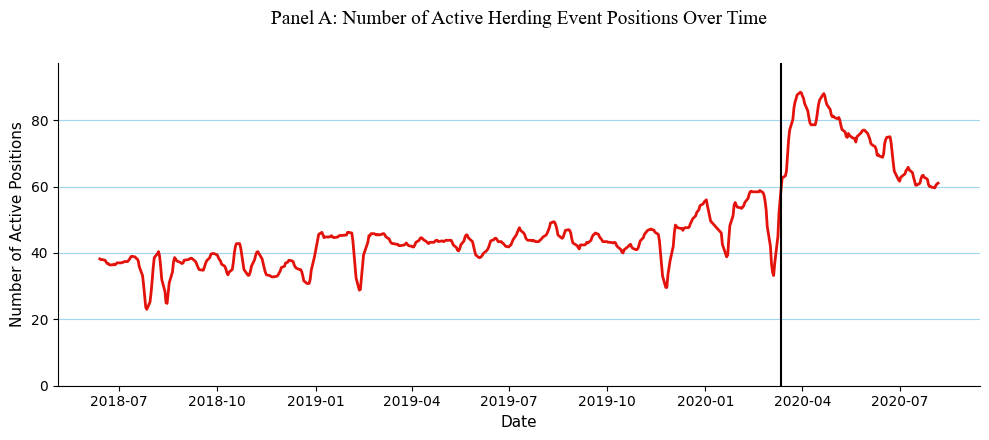

In [133]:
# Prepare data for plotting 
plot_active = portfolio_returns.dropna(subset=["n_active_positions"]).copy()
plot_active = plot_active.sort_values("date").reset_index(drop=True)
plot_active = plot_active.loc[(plot_active['date'] >= pd.to_datetime("2018-06-09")) & (plot_active['date'] <= pd.to_datetime("2020-08-10"))].copy()

# rolling average for smoother visualization
plot_active["n_active_positions"] = plot_active["n_active_positions"].rolling(window=5, center=True).mean()
plot_active = plot_active.dropna(subset=["n_active_positions"]).copy()


# plot
fig, ax1 = plt.subplots(figsize=(10, 4.5))
color = "#E3120B"
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylim(0, plot_active["n_active_positions"].max() * 1.1)
ax1.set_ylabel("Number of Active Positions", fontsize=11)
ax1.plot(plot_active["date"], plot_active["n_active_positions"], color=color, linewidth=2)
ax1.axvline(x=pd.to_datetime("2020-03-12"), color="black", linestyle="-", linewidth=1.5)
ax1.tick_params(axis="y")
ax1.set_title(
    "Panel A: Number of Active Herding Event Positions Over Time",
    fontsize=14,
    pad=28,
    family="Times New Roman"
)
ax1.grid(alpha=0.8, color="skyblue", axis="y")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../../../figures/panelA_active_positions.pdf", bbox_inches="tight")
plt.show()

### 3.2. Returns Analysis 

I now load Fama-French factors

In [134]:
# load fama french
ff = pd.read_csv("../../../data/interim/5f_cleaned.csv")

# datetime
ff["date"] = pd.to_datetime(ff["date"], format="%Y-%m-%d")

ff = ff.sort_values("date").reset_index(drop=True)

# convert returns to decimal
ff['rf'] = ff['rf'] / 100
ff['mkt_rf'] = ff['mkt_rf'] / 100

# head
ff.head()

,date,mkt_rf,smb,hml,rmw,cma,rf
0,2018-01-02,0.0085,0.32,-0.21,-0.51,0.22,0.0001
1,2018-01-03,0.0059,-0.47,-0.19,-0.71,-0.07,0.0001
2,2018-01-04,0.0042,-0.22,0.24,-0.02,0.30,0.0001
3,2018-01-05,0.0066,-0.37,-0.25,0.39,-0.38,0.0001
4,2018-01-08,0.0019,-0.20,0.04,-0.06,0.04,0.0001


I now merged the fama-french factor with my portfolio dataset:

In [135]:
# merge with portfolio returns
ff_portfolio = ff.merge(portfolio_returns, on="date", how="right")

# head
ff_portfolio.head()

,date,mkt_rf,smb,hml,rmw,cma,rf,rp,n_active_positions,n_unique_tickers
0,2018-05-07,0.0041,0.38,-0.33,-0.55,-0.32,0.0001,-0.056704,1,1
1,2018-05-08,0.0007,0.50,0.23,-0.29,0.08,0.0001,-0.032022,1,1
2,2018-05-09,0.0090,-0.26,0.25,-0.92,-0.03,0.0001,0.167731,1,1
3,2018-05-10,0.0085,-0.38,-0.04,0.24,-0.31,0.0001,0.006353,8,8
4,2018-05-11,0.0019,0.13,-0.38,0.26,0.12,0.0001,-0.008456,15,15


I compare cumulative returns over the period with the market.

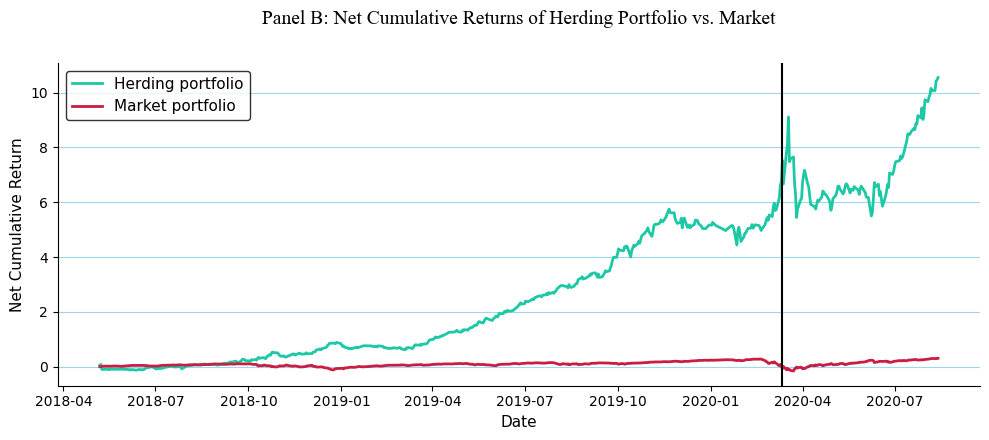

In [136]:
# plotting data prep
df_cum = ff_portfolio[["date", "rp", "mkt_rf", "rf"]].copy()

# cumulative return of the (short) strategy
df_cum["rp"] = -1 * df_cum["rp"]  # reverse sign to have a short strategy
df_cum["cumulative_rp"] = (1 + df_cum["rp"].fillna(0)).cumprod() - 1

# cumulative return of the market (MKT)
df_cum["mkt"] = df_cum["mkt_rf"] + df_cum["rf"]
df_cum["cumulative_mkt"] = (1 + df_cum["mkt"].fillna(0)).cumprod() - 1

# plot
fig, ax1 = plt.subplots(figsize=(10, 4.5))
color = "#1DC9A4"
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Net Cumulative Return", fontsize=11)
ax1.plot(df_cum["date"], df_cum["cumulative_rp"], color=color, linewidth=2, label="Herding portfolio")
ax1.plot(df_cum["date"], df_cum["cumulative_mkt"], color="#C91D42", linewidth=2, label="Market portfolio")
ax1.axvline(x=pd.to_datetime("2020-03-12"), color="black", linestyle="-", linewidth=1.5)
ax1.tick_params(axis="y")
ax1.set_title(
    "Panel B: Net Cumulative Returns of Herding Portfolio vs. Market",
    fontsize=14,
    pad=28,
    family="Times New Roman"
)
ax1.grid(alpha=0.8, color="skyblue", axis="y")
ax1.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="black", fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../../../figures/panelB_cumulative_returns.pdf", bbox_inches="tight")
plt.show()

#### Regression Analysis

I now perform the regression mentioned above.

In [129]:
import statsmodels.formula.api as smf

# prepare data for regression
df_reg = ff_portfolio.copy()

# make sure date is datetime
df_reg["date"] = pd.to_datetime(df_reg["date"])

# filter sample by date range
# no filter
pass

# filter sample before March 12, 2020
# df_reg = df_reg[df_reg["date"] < pd.to_datetime("2020-03-12")].copy()

# filter sample after March 12, 2020
# df_reg = df_reg[df_reg["date"] >= pd.to_datetime("2020-03-12")].copy()

# excess return of the herding portfolio, short strategy
df_reg["excess_rp"] = (- 1 * df_reg["rp"]) - df_reg["rf"]

# fama-french factors in decimal
df_reg["smb"] = df_reg["smb"] / 100
df_reg["hml"] = df_reg["hml"] / 100
df_reg["rmw"] = df_reg["rmw"] / 100
df_reg["cma"] = df_reg["cma"] / 100

# drop rows with missing values
df_reg = df_reg.dropna(
    subset=[
        "excess_rp",
        "mkt_rf",
        "smb",
        "hml",
        "rmw",
        "cma"
    ]
).copy()

# regression formula
formula = "excess_rp ~ mkt_rf + smb + hml + rmw + cma"

# estimate with HAC standard errors
model = smf.ols(formula=formula, data=df_reg).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5},
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              excess_rp   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     79.60
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           7.54e-63
Time:                        16:26:19   Log-Likelihood:                 1326.4
No. Observations:                 559   AIC:                            -2641.
Df Residuals:                     553   BIC:                            -2615.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0004      0.001     -0.406      0.6

The estimated intercept is 0.43\% per day and is statistically significant at the 1\% level. This suggests that a calendar-time strategy that shorts stocks following Robinhood herding episodes earns positive abnormal returns even after controlling for exposure to the Fama--French five factors. The result is consistent with the interpretation that herding episodes are followed by return reversals rather than compensation for standard factor risk.

The short herding strategy has a negative market beta. When the market excess return increases by 1 percentage point, the short strategy return decreases by about 0.68 percentage points, holding other factors constant. This is intuitive if the underlying herding portfolio is long high-attention stocks that tend to move positively with the market; shorting it creates negative market exposure.

The negative SMB loading means the short strategy behaves more like a large-cap tilt, or equivalently that the long herding portfolio has positive small-stock exposure. This is plausible if herding events are concentrated among smaller or more speculative stocks.

The negative HML loading means the short strategy has a growth tilt, or equivalently that the long herding portfolio loads positively on value relative to the short position. Check this interpretation carefully against your sample composition, because HML signs can be less intuitive depending on the underlying stocks.

The positive RMW coefficient means the short strategy loads positively on the profitability factor. The positive CMA coefficient means it loads positively on the conservative-minus-aggressive investment factor. These are risk exposures that the regression controls for; the main point is that the alpha remains positive after absorbing them.

#### subsamples results

pre-covid (March 12, 2020)

during covid

attention sample for full period

## 4. Further Regression Results

$$
R_{i, t} = a + \sum_{k = 1}^{5} b_k \textit{rh\_herd}_{i, t - k} + \sum_{c = 1}^{5} c_k \textit{taq\_retimb}_{i, t - k} + \sum_{k = 1}^{5} d_k R_{i, t - k} + u_t + e_{i, t}
$$

In [141]:
# ------------------------------------------------------------
# Lagged return predictability regression
# ------------------------------------------------------------
import statsmodels.formula.api as smf

# Work on a clean copy and ensure chronological ordering within stocks
LAGS = range(1, 4)
LAG_BASE_VARS = ["rh_herd", "taq_retimb", "ret"]

required_cols = ["ticker", "date", "ret"] + LAG_BASE_VARS
missing_cols = [col for col in required_cols if col not in base.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in base: {missing_cols}")

df_lagereg = (
    base
    .copy()
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

# Create lags t-1 to t-5 within each stock
for var in LAG_BASE_VARS:
    for lag in LAGS:
        df_lagereg[f"{var}_lag{lag}"] = (
            df_lagereg
            .groupby("ticker", sort=False)[var]
            .shift(lag)
        )

# Define regression variables explicitly
lag_cols = [f"{var}_lag{lag}" for var in LAG_BASE_VARS for lag in LAGS]
reg_cols = ["date", "ticker", "ret"] + lag_cols

# Drop all rows with missing values in either the outcome, regressors, or cluster variable.
# This is crucial: the clustering vector must have exactly the same length as the
# sample actually used by statsmodels.
df_lagereg_model = (
    df_lagereg[reg_cols]
    .dropna(subset=["date", "ret"] + lag_cols)
    .copy()
)

# Optional but useful: convert dates to categorical cluster labels
# to avoid dtype issues in statsmodels' clustered covariance routine.
df_lagereg_model["date_cluster"] = df_lagereg_model["date"].astype("category").cat.codes

# Build formula
rhs_terms = " + ".join(lag_cols)
formula_lag = f"ret ~ {rhs_terms}"

# Sanity checks before estimation
assert len(df_lagereg_model) == len(df_lagereg_model["date_cluster"])
print(f"Regression sample: {len(df_lagereg_model):,} observations")
print(f"Number of day clusters: {df_lagereg_model['date'].nunique():,}")

# OLS with standard errors clustered by trading day
model_lag = smf.ols(
    formula=formula_lag,
    data=df_lagereg_model,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_lagereg_model["date_cluster"]},
)

print(model_lag.summary())

Regression sample: 3,474,188 observations
Number of day clusters: 562
                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     5.668
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.57e-07
Time:                        17:14:06   Log-Likelihood:             5.9858e+06
No. Observations:             3474188   AIC:                        -1.197e+07
Df Residuals:                 3474178   BIC:                        -1.197e+07
Df Model:                           9                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

no statistical significance achieved.

## 5. TAQ herding events

In [165]:
df_taq = base.copy()

I construct a TAQ-based abnormal buying indicator designed to capture days on which retail buying pressure is both directionally strong and unusually intense. For each stock $i$ and trading day $t$, I first define retail order imbalance as
$$
    \textit{taq\_retimb}_{i,t}
    =
    \frac{\textit{daily\_buys}_{i,t}-\textit{daily\_sells}_{i,t}}
    {\textit{daily\_buys}_{i,t}+\textit{daily\_sells}_{i,t}}.
$$
I then define abnormal retail volume as
$$
    \textit{abn\_retail\_volume}_{i,t}
    =
    \frac{\textit{daily\_buys}_{i,t}+\textit{daily\_sells}_{i,t}}
    {\frac{1}{20}\sum_{k=1}^{20}
    \left(\textit{daily\_buys}_{i,t-k}+\textit{daily\_sells}_{i,t-k}\right)}.
$$
The TAQ abnormal buying indicator equals one if stock $i$ is in the top quintile of retail order imbalance on day $t$ and, within the same trading day, also belongs to the top decile of abnormal retail volume:
$$
    \textit{taq\_buyherd}_{i,t}
    =
    \mathbf{1}\left[
    \textit{taq\_retimb}_{i,t}
    \geq Q_{0.80,t}(\textit{taq\_retimb})
    \right]
    \times
    \mathbf{1}\left[
    \textit{abn\_retail\_volume}_{i,t}
    \geq Q_{0.90,t}(\textit{abn\_retail\_volume})
    \right].
$$
This definition follows the logic of Barber et al. (2022), who identify TAQ herding
episodes using high standardized retail order imbalance together with abnormal retail
volume.

In [189]:
df_taq["date"] = pd.to_datetime(df_taq["date"])
df_taq = df_taq.sort_values(["ticker", "date"])

# 1. Retail trading measures
df_taq["retail_volume"] = df_taq["daily_buys"] + df_taq["daily_sells"]
df_taq["net_buys"] = df_taq["daily_buys"] - df_taq["daily_sells"]

df_taq["taq_retimb"] = np.where(
    df_taq["retail_volume"] > 0,
    df_taq["net_buys"] / df_taq["retail_volume"],
    np.nan
)

# 2. Lagged 20-day average retail volume
df_taq["retail_volume_lag20_mean"] = (
    df_taq.groupby("ticker")["retail_volume"]
      .transform(lambda x: x.shift(1).rolling(20, min_periods=20).mean())
)

# 3. Abnormal retail volume
df_taq["abn_retail_volume"] = np.where(
    df_taq["retail_volume_lag20_mean"] > 0,
    df_taq["retail_volume"] / df_taq["retail_volume_lag20_mean"],
    np.nan
)

# 4. Daily cross-sectional thresholds
df_taq["taq_retimb_threshold"] = (
    df_taq.groupby("date")["taq_retimb"]
      .transform(lambda x: x.quantile(0.75))
)

# count the number of Robinhood herding events on each day = N
# and then the TAQ herding events will be the first N stocks with
# the highest abn_retail_volume
df_taq["daily_herding_rank"] = (
    df_taq.groupby("date")["abn_retail_volume"]
      .rank(method="first", ascending=False)
)
daily_rh_herding_counts = (
    df_taq[df_taq["rh_herd"] == 1]
      .groupby("date")      .size()
      .rename("daily_rh_herding_count")
)
df_taq = df_taq.merge(daily_rh_herding_counts, on="date", how="left")
df_taq["daily_rh_herding_count"] = df_taq["daily_rh_herding_count"].fillna(0).astype(int)
df_taq["taq_herd"] = df_taq["daily_herding_rank"] <= df_taq["daily_rh_herding_count"]

# number of TAQ herding events in sample
n_taq_herding_events = df_taq["taq_herd"].sum()
print(f"Number of TAQ herding events: {n_taq_herding_events:,}")

Number of TAQ herding events: 5,227


In [190]:
# percentage of overlap with rh_herd events
overlap_events = df_taq.loc[df_taq["taq_herd"] == 1, "rh_herd"].sum()
print(f"Number of TAQ herding events that are also RH herding events: {overlap_events:,}")
print(f"Percentage of TAQ herding events that are also RH herding events: {overlap_events / n_taq_herd_events:.2%}")

Number of TAQ herding events that are also RH herding events: 1,979
Percentage of TAQ herding events that are also RH herding events: 44.32%


I now build my portfolio

In [191]:
taq_portfolio_ret, taq_active_pos =  build_herding_calendar_time_portfolio(
    df=df_taq,
    date_col="date",
    ticker_col="ticker",
    event_col="taq_herd",
    ret_col="ret",
    holding_days=5
)

I inspect the dataset

In [192]:
taq_portfolio_ret.head()

,date,rp,n_active_positions,n_unique_tickers
0,2018-06-01,-0.023094,8,8
1,2018-06-04,0.028781,15,14
2,2018-06-05,0.003716,23,22
3,2018-06-06,-0.004056,31,30
4,2018-06-07,-0.016392,38,37


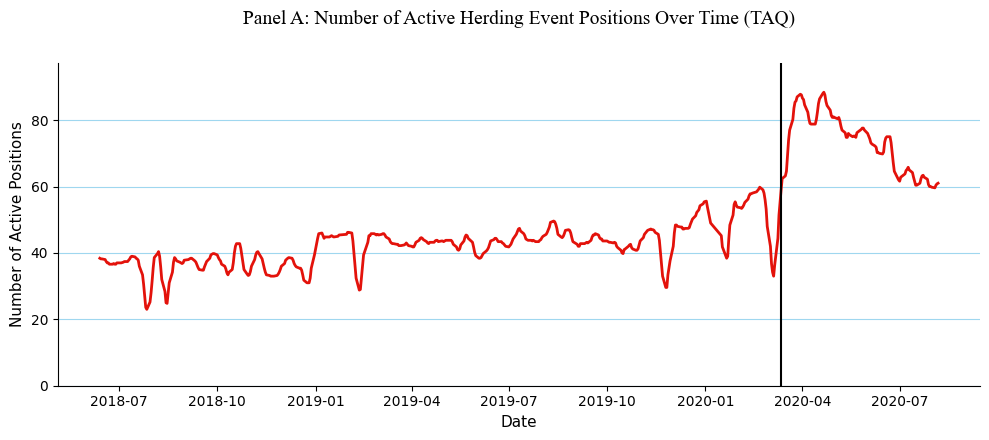

In [193]:
# Prepare data for plotting 
plot_active_taq = taq_portfolio_ret.dropna(subset=["n_active_positions"]).copy()
plot_active_taq = plot_active_taq.sort_values("date").reset_index(drop=True)
plot_active_taq = plot_active_taq.loc[(plot_active_taq['date'] >= pd.to_datetime("2018-06-09")) & (plot_active_taq['date'] <= pd.to_datetime("2020-08-10"))].copy()

# rolling average for smoother visualization
plot_active_taq["n_active_positions"] = plot_active_taq["n_active_positions"].rolling(window=5, center=True).mean()
plot_active_taq = plot_active_taq.dropna(subset=["n_active_positions"]).copy()


# plot
fig, ax1 = plt.subplots(figsize=(10, 4.5))
color = "#E3120B"
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylim(0, plot_active_taq["n_active_positions"].max() * 1.1)
ax1.set_ylabel("Number of Active Positions", fontsize=11)
ax1.plot(plot_active_taq["date"], plot_active_taq["n_active_positions"], color=color, linewidth=2)
ax1.axvline(x=pd.to_datetime("2020-03-12"), color="black", linestyle="-", linewidth=1.5)
ax1.tick_params(axis="y")
ax1.set_title(
    "Panel A: Number of Active Herding Event Positions Over Time (TAQ)",
    fontsize=14,
    pad=28,
    family="Times New Roman"
)
ax1.grid(alpha=0.8, color="skyblue", axis="y")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../../../figures/panelA_active_positions_taq.pdf", bbox_inches="tight")
plt.show()

In [194]:
ff_taq_portfolio = ff.merge(taq_portfolio_ret, on="date", how="right")
ff_taq_portfolio.head()

,date,mkt_rf,smb,hml,rmw,cma,rf,rp,n_active_positions,n_unique_tickers
0,2018-06-01,0.0106,-0.21,-0.10,-0.07,-0.20,0.0001,-0.023094,8,8
1,2018-06-04,0.0048,0.17,-0.45,1.08,-0.32,0.0001,0.028781,15,14
2,2018-06-05,0.0016,0.78,-0.44,0.20,0.08,0.0001,0.003716,23,22
3,2018-06-06,0.0086,-0.27,0.21,0.01,0.16,0.0001,-0.004056,31,30
4,2018-06-07,-0.0014,-0.25,0.93,0.17,0.62,0.0001,-0.016392,38,37


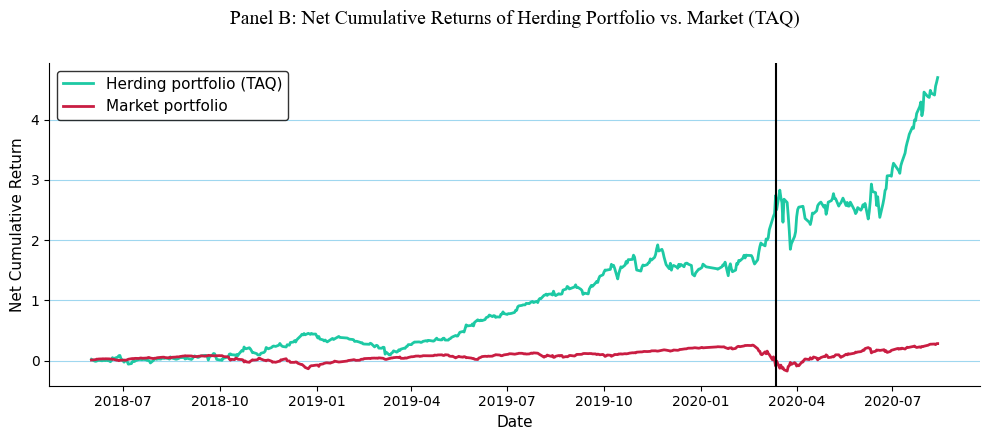

In [195]:
# plotting data prep
df_cum_taq = ff_taq_portfolio[["date", "rp", "mkt_rf", "rf"]].copy()

# cumulative return of the (short) strategy
df_cum_taq["rp"] = -1 * df_cum_taq["rp"]  # reverse sign to have a short strategy
df_cum_taq["cumulative_rp"] = (1 + df_cum_taq["rp"].fillna(0)).cumprod() - 1

# cumulative return of the market (MKT)
df_cum_taq["mkt"] = df_cum_taq["mkt_rf"] + df_cum_taq["rf"]
df_cum_taq["cumulative_mkt"] = (1 + df_cum_taq["mkt"].fillna(0)).cumprod() - 1

# plot
fig, ax1 = plt.subplots(figsize=(10, 4.5))
color = "#1DC9A4"
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Net Cumulative Return", fontsize=11)
ax1.plot(df_cum_taq["date"], df_cum_taq["cumulative_rp"], color=color, linewidth=2, label="Herding portfolio (TAQ)")
ax1.plot(df_cum_taq["date"], df_cum_taq["cumulative_mkt"], color="#C91D42", linewidth=2, label="Market portfolio")
ax1.axvline(x=pd.to_datetime("2020-03-12"), color="black", linestyle="-", linewidth=1.5)
ax1.tick_params(axis="y")
ax1.set_title(
    "Panel B: Net Cumulative Returns of Herding Portfolio vs. Market (TAQ)",
    fontsize=14,
    pad=28,
    family="Times New Roman"
)
ax1.grid(alpha=0.8, color="skyblue", axis="y")
ax1.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="black", fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../../../figures/panelB_cumulative_returns_taq.pdf", bbox_inches="tight")
plt.show()

In [196]:
import statsmodels.formula.api as smf

# prepare data for regression
df_reg_taq = ff_taq_portfolio.copy()

# make sure date is datetime
df_reg_taq["date"] = pd.to_datetime(df_reg_taq["date"])

# filter sample by date range
# no filter
pass

# filter sample before March 12, 2020
# df_reg_taq = df_reg_taq[df_reg_taq["date"] < pd.to_datetime("2020-03-12")].copy()

# filter sample after March 12, 2020
# df_reg_taq = df_reg_taq[df_reg_taq["date"] >= pd.to_datetime("2020-03-12")].copy()

# excess return of the herding portfolio, short strategy
df_reg_taq["excess_rp"] = (- 1 * df_reg_taq["rp"]) - df_reg_taq["rf"]

# fama-french factors in decimal
df_reg_taq["smb"] = df_reg_taq["smb"] / 100
df_reg_taq["hml"] = df_reg_taq["hml"] / 100
df_reg_taq["rmw"] = df_reg_taq["rmw"] / 100
df_reg_taq["cma"] = df_reg_taq["cma"] / 100

# drop rows with missing values
df_reg_taq = df_reg_taq.dropna(
    subset=[
        "excess_rp",
        "mkt_rf",
        "smb",
        "hml",
        "rmw",
        "cma"
    ]
).copy()

# regression formula
formula = "excess_rp ~ mkt_rf + smb + hml + rmw + cma"

# estimate with HAC standard errors
model = smf.ols(formula=formula, data=df_reg_taq).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5},
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              excess_rp   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     34.16
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           2.49e-30
Time:                        18:16:14   Log-Likelihood:                 1345.9
No. Observations:                 544   AIC:                            -2680.
Df Residuals:                     538   BIC:                            -2654.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0032      0.001      3.953      0.0